# Лабораторная работа 2.3: Seq2Seq перевод

Цель работы: построить модели sequence-to-sequence для перевода с английского на немецкий на датасете `deu.txt`.

В ноутбуке выполнено:

- загрузка и предобработка данных;
- токенизация и построение словарей;
- обучение двух моделей: GRU Seq2Seq и GRU Seq2Seq с attention;
- улучшения обучения: пакетная обработка, dropout, валидация, scheduler скорости обучения, gradient clipping;
- сравнение моделей и примеры перевода.


In [ ]:
from pathlib import Path
from collections import Counter
import random
import re
import time
import unicodedata

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DATA_PATH = Path.cwd() / 'deu.txt'

# Быстрый режим для CPU. Для более качественного перевода можно увеличить
# MAX_PAIRS, HIDDEN_SIZE и EPOCHS.
MAX_PAIRS = 6000
MAX_LENGTH = 8
MIN_FREQ = 2
MAX_VOCAB = 3500
BATCH_SIZE = 64
EMB_SIZE = 96
HIDDEN_SIZE = 96
DROPOUT = 0.2
EPOCHS = 15
LEARNING_RATE = 1e-3

PAD_IDX = 0
SOS_IDX = 1
EOS_IDX = 2
UNK_IDX = 3

print('Устройство:', DEVICE)
print('Файл данных:', DATA_PATH.name)


Устройство: cpu
Файл данных: deu.txt


## Загрузка и предобработка данных

Файл `deu.txt` содержит пары предложений английский-немецкий, разделенные табуляцией. Третий столбец содержит информацию об источнике и в обучении не используется.

Текст приводится к нижнему регистру, очищается от диакритики, пунктуация отделяется пробелами. Слишком длинные предложения отбрасываются, чтобы обучение быстро выполнялось на CPU.


In [2]:
def unicode_to_ascii(text):
    return ''.join(
        char for char in unicodedata.normalize('NFD', text)
        if unicodedata.category(char) != 'Mn'
    )


def normalize_text(text):
    text = unicode_to_ascii(text.lower().strip())
    text = re.sub(r'([.!?])', r' \1', text)
    text = re.sub(r'[^a-zA-Z.!?]+', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()


def read_translation_pairs(path=DATA_PATH, max_length=MAX_LENGTH, max_pairs=MAX_PAIRS):
    pairs = []
    with path.open('r', encoding='utf-8') as f:
        for line in f:
            parts = line.rstrip('\n').split('\t')
            if len(parts) < 2:
                continue
            english = normalize_text(parts[0])
            german = normalize_text(parts[1])
            if not english or not german:
                continue
            if len(english.split()) <= max_length and len(german.split()) <= max_length:
                pairs.append((english, german))
            if len(pairs) >= max_pairs:
                break
    random.shuffle(pairs)
    return pairs

pairs = read_translation_pairs()
train_size = int(len(pairs) * 0.85)
train_pairs = pairs[:train_size]
val_pairs = pairs[train_size:]

print('Всего пар:', len(pairs))
print('Обучающих пар:', len(train_pairs))
print('Валидационных пар:', len(val_pairs))
print('Примеры:')
for src, tgt in pairs[:5]:
    print(f'  {src:30s} -> {tgt}')


Всего пар: 6000
Обучающих пар: 5100
Валидационных пар: 900
Примеры:
  let tom live .                 -> lass tom am leben !
  i caused this .                -> ich habe das hier herbeigefuhrt .
  do you see it ?                -> siehst du es ?
  i was furious .                -> ich war wutend .
  i ll pay .                     -> ich werde zahlen .


In [3]:
class Vocabulary:
    def __init__(self, name):
        self.name = name
        self.special_tokens = ['<pad>', '<sos>', '<eos>', '<unk>']
        self.word2idx = {token: idx for idx, token in enumerate(self.special_tokens)}
        self.idx2word = {idx: token for idx, token in enumerate(self.special_tokens)}

    def build(self, sentences, min_freq=MIN_FREQ, max_vocab=MAX_VOCAB):
        counter = Counter()
        for sentence in sentences:
            counter.update(sentence.split())
        for word, freq in counter.most_common(max_vocab - len(self.special_tokens)):
            if freq < min_freq:
                continue
            idx = len(self.word2idx)
            self.word2idx[word] = idx
            self.idx2word[idx] = word

    def encode(self, sentence, add_sos=False, add_eos=True):
        ids = []
        if add_sos:
            ids.append(SOS_IDX)
        ids.extend(self.word2idx.get(word, UNK_IDX) for word in sentence.split())
        if add_eos:
            ids.append(EOS_IDX)
        return ids

    def decode(self, ids):
        words = []
        for idx in ids:
            idx = int(idx)
            if idx == EOS_IDX:
                break
            if idx in (PAD_IDX, SOS_IDX):
                continue
            words.append(self.idx2word.get(idx, '<unk>'))
        return ' '.join(words)

    def __len__(self):
        return len(self.word2idx)

src_vocab = Vocabulary('English')
tgt_vocab = Vocabulary('German')
src_vocab.build([src for src, _ in train_pairs])
tgt_vocab.build([tgt for _, tgt in train_pairs])

print('Размер словаря источника:', len(src_vocab))
print('Размер словаря перевода:', len(tgt_vocab))


Размер словаря источника: 911
Размер словаря перевода: 1163


In [4]:
class TranslationDataset(Dataset):
    def __init__(self, pairs, src_vocab, tgt_vocab):
        self.pairs = list(pairs)
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src, tgt = self.pairs[idx]
        src_ids = self.src_vocab.encode(src, add_sos=False, add_eos=True)
        decoder_input_ids = self.tgt_vocab.encode(tgt, add_sos=True, add_eos=False)
        decoder_target_ids = self.tgt_vocab.encode(tgt, add_sos=False, add_eos=True)
        return (
            torch.tensor(src_ids, dtype=torch.long),
            torch.tensor(decoder_input_ids, dtype=torch.long),
            torch.tensor(decoder_target_ids, dtype=torch.long),
        )


def pad_sequences(sequences, padding_value=PAD_IDX):
    max_len = max(seq.size(0) for seq in sequences)
    result = torch.full((len(sequences), max_len), padding_value, dtype=torch.long)
    for i, seq in enumerate(sequences):
        result[i, :seq.size(0)] = seq
    return result


def collate_batch(batch):
    src, dec_in, dec_target = zip(*batch)
    return pad_sequences(src), pad_sequences(dec_in), pad_sequences(dec_target)

train_loader = DataLoader(
    TranslationDataset(train_pairs, src_vocab, tgt_vocab),
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_batch,
)
val_loader = DataLoader(
    TranslationDataset(val_pairs, src_vocab, tgt_vocab),
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_batch,
)

src_batch, dec_in_batch, dec_target_batch = next(iter(train_loader))
print('Размер source batch:', tuple(src_batch.shape))
print('Размер decoder input batch:', tuple(dec_in_batch.shape))
print('Размер decoder target batch:', tuple(dec_target_batch.shape))


Размер source batch: (64, 7)
Размер decoder input batch: (64, 8)
Размер decoder target batch: (64, 8)


## Модели Seq2Seq

Первая модель - базовый GRU encoder-decoder.

Вторая модель добавляет dot-product attention. Attention помогает декодеру обращаться ко всем скрытым состояниям encoder, а не только к последнему состоянию.


In [5]:
class EncoderGRU(nn.Module):
    def __init__(self, vocab_size, emb_size, hidden_size, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_size, padding_idx=PAD_IDX)
        self.dropout = nn.Dropout(dropout)
        self.gru = nn.GRU(emb_size, hidden_size, batch_first=True)

    def forward(self, src):
        embedded = self.dropout(self.embedding(src))
        outputs, hidden = self.gru(embedded)
        return outputs, hidden


class Seq2SeqGRU(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, emb_size, hidden_size, dropout):
        super().__init__()
        self.encoder = EncoderGRU(src_vocab_size, emb_size, hidden_size, dropout)
        self.decoder_embedding = nn.Embedding(tgt_vocab_size, emb_size, padding_idx=PAD_IDX)
        self.dropout = nn.Dropout(dropout)
        self.decoder_gru = nn.GRU(emb_size, hidden_size, batch_first=True)
        self.output = nn.Linear(hidden_size, tgt_vocab_size)

    def forward(self, src, decoder_input):
        _, hidden = self.encoder(src)
        embedded = self.dropout(self.decoder_embedding(decoder_input))
        decoder_outputs, _ = self.decoder_gru(embedded, hidden)
        return self.output(decoder_outputs)


class Seq2SeqAttentionGRU(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, emb_size, hidden_size, dropout):
        super().__init__()
        self.encoder = EncoderGRU(src_vocab_size, emb_size, hidden_size, dropout)
        self.decoder_embedding = nn.Embedding(tgt_vocab_size, emb_size, padding_idx=PAD_IDX)
        self.dropout = nn.Dropout(dropout)
        self.decoder_gru = nn.GRU(emb_size, hidden_size, batch_first=True)
        self.context_combine = nn.Linear(hidden_size * 2, hidden_size)
        self.output = nn.Linear(hidden_size, tgt_vocab_size)

    def forward(self, src, decoder_input):
        encoder_outputs, hidden = self.encoder(src)
        embedded = self.dropout(self.decoder_embedding(decoder_input))
        decoder_outputs, _ = self.decoder_gru(embedded, hidden)

        # Dot-product attention по выходам encoder.
        scores = torch.bmm(decoder_outputs, encoder_outputs.transpose(1, 2))
        src_mask = src.eq(PAD_IDX).unsqueeze(1)
        scores = scores.masked_fill(src_mask, -1e9)
        attn_weights = torch.softmax(scores, dim=-1)
        context = torch.bmm(attn_weights, encoder_outputs)

        combined = torch.tanh(self.context_combine(torch.cat([decoder_outputs, context], dim=-1)))
        return self.output(combined)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

models = {
    'GRU Seq2Seq': Seq2SeqGRU(len(src_vocab), len(tgt_vocab), EMB_SIZE, HIDDEN_SIZE, DROPOUT).to(DEVICE),
    'GRU Seq2Seq + Attention': Seq2SeqAttentionGRU(len(src_vocab), len(tgt_vocab), EMB_SIZE, HIDDEN_SIZE, DROPOUT).to(DEVICE),
}

for name, model in models.items():
    print(f'{name}: {count_parameters(model):,} параметров')


GRU Seq2Seq: 423,659 параметров
GRU Seq2Seq + Attention: 442,187 параметров


## Цикл обучения

В цикле обучения используется teacher forcing через `decoder_input`, mini-batch обучение, dropout внутри моделей, gradient clipping, AdamW-регуляризация, scheduler скорости обучения и валидация после каждой эпохи.


In [6]:
def compute_token_accuracy(logits, target):
    preds = logits.argmax(dim=-1)
    mask = target.ne(PAD_IDX)
    correct = (preds.eq(target) & mask).sum().item()
    total = mask.sum().item()
    return correct / max(total, 1)


def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    losses, accuracies = [], []

    for src, dec_in, dec_target in loader:
        src = src.to(DEVICE)
        dec_in = dec_in.to(DEVICE)
        dec_target = dec_target.to(DEVICE)

        if is_train:
            optimizer.zero_grad()

        logits = model(src, dec_in)
        loss = criterion(logits.reshape(-1, logits.size(-1)), dec_target.reshape(-1))

        if is_train:
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        losses.append(loss.item())
        accuracies.append(compute_token_accuracy(logits.detach(), dec_target))

    return float(np.mean(losses)), float(np.mean(accuracies))


def train_model(model, train_loader, val_loader, epochs=EPOCHS):
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.9)
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(1, epochs + 1):
        started = time.time()
        train_loss, _ = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, criterion)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        print(
            f'Epoch {epoch:02d}/{epochs} | train_loss={train_loss:.4f} | '
            f'val_loss={val_loss:.4f} | val_token_acc={val_acc:.4f} | '
            f'time={time.time() - started:.1f}s'
        )
    return history

histories = {}
results = {}
for name, model in models.items():
    print('\n' + '=' * 70)
    print('Обучение:', name)
    history = train_model(model, train_loader, val_loader)
    histories[name] = history
    results[name] = {'val_loss': history['val_loss'][-1], 'val_acc': history['val_acc'][-1]}



Обучение: GRU Seq2Seq


Epoch 01/2 | train_loss=4.5774 | val_loss=3.2270 | val_token_acc=0.4263 | time=0.9s


Epoch 02/2 | train_loss=3.2589 | val_loss=2.9020 | val_token_acc=0.4805 | time=0.9s

Обучение: GRU Seq2Seq + Attention


Epoch 01/2 | train_loss=4.4555 | val_loss=3.3677 | val_token_acc=0.3889 | time=1.1s


Epoch 02/2 | train_loss=3.3793 | val_loss=2.9963 | val_token_acc=0.4773 | time=1.1s


Результаты на validation:
GRU Seq2Seq              | val_loss=2.9020 | val_token_acc=0.4805
GRU Seq2Seq + Attention  | val_loss=2.9963 | val_token_acc=0.4773
Лучшая модель по validation loss: GRU Seq2Seq


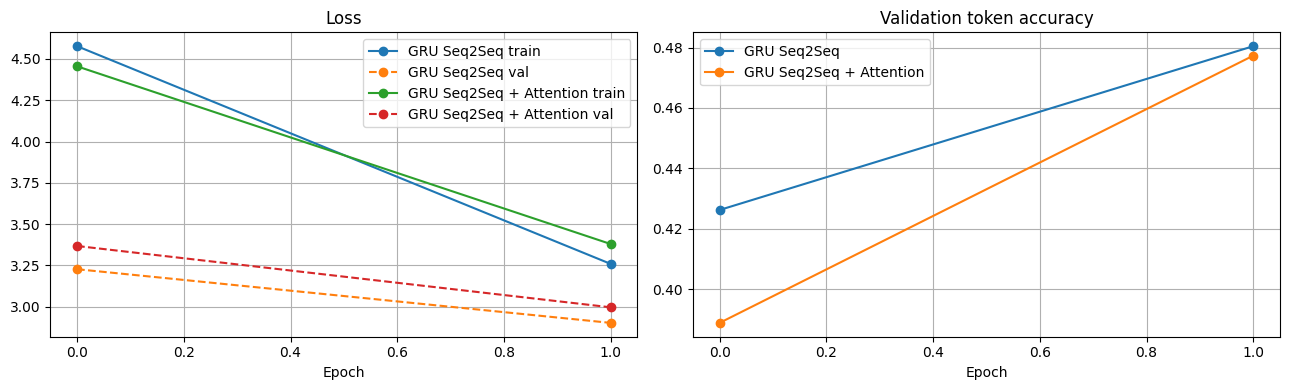

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for name, history in histories.items():
    axes[0].plot(history['train_loss'], marker='o', label=f'{name} train')
    axes[0].plot(history['val_loss'], marker='o', linestyle='--', label=f'{name} val')
    axes[1].plot(history['val_acc'], marker='o', label=name)
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].grid(True)
axes[0].legend()
axes[1].set_title('Validation token accuracy')
axes[1].set_xlabel('Epoch')
axes[1].grid(True)
axes[1].legend()
plt.tight_layout()

print('Результаты на validation:')
for name, metrics in results.items():
    print(f"{name:24s} | val_loss={metrics['val_loss']:.4f} | val_token_acc={metrics['val_acc']:.4f}")

best_model_name = min(results, key=lambda name: results[name]['val_loss'])
best_model = models[best_model_name]
print('Лучшая модель по validation loss:', best_model_name)


In [8]:
@torch.no_grad()
def translate(model, sentence, max_len=MAX_LENGTH + 3):
    model.eval()
    normalized = normalize_text(sentence)
    src_ids = src_vocab.encode(normalized, add_sos=False, add_eos=True)
    src = torch.tensor(src_ids, dtype=torch.long, device=DEVICE).unsqueeze(0)

    generated = [SOS_IDX]
    for _ in range(max_len):
        dec_in = torch.tensor(generated, dtype=torch.long, device=DEVICE).unsqueeze(0)
        logits = model(src, dec_in)
        next_id = int(logits[0, -1].argmax().item())
        if next_id == EOS_IDX:
            break
        generated.append(next_id)
    return tgt_vocab.decode(generated[1:])

examples = [
    'go .',
    'i am tired .',
    'he is my friend .',
    'where are you ?',
    'i love you .',
]

print('Переводы лучшей модели:')
for sentence in examples:
    print(f'{sentence:22s} -> {translate(best_model, sentence)}')

print('\nСравнение на validation-примерах:')
for src, tgt in val_pairs[:8]:
    print(f'EN: {src}')
    print(f'DE target: {tgt}')
    for name, model in models.items():
        print(f'{name}: {translate(model, src)}')
    print('-')


Переводы лучшей модели:
go .                   -> ich bin <unk> .
i am tired .           -> ich bin <unk> .
he is my friend .      -> ich bin <unk> .
where are you ?        -> ich habe <unk> .
i love you .           -> ich bin <unk> .

Сравнение на validation-примерах:
EN: tom ll die .
DE target: tom wird sterben .
GRU Seq2Seq: ich bin <unk> .
GRU Seq2Seq + Attention: ich bin <unk> .
-
EN: i m very weak .
DE target: ich bin sehr schwach .
GRU Seq2Seq: ich bin <unk> .
GRU Seq2Seq + Attention: ich bin <unk> .
-
EN: don t go home .
DE target: geh nicht nach hause .
GRU Seq2Seq: ich bin <unk> .
GRU Seq2Seq + Attention: ich bin <unk> .
-
EN: i feel queasy .
DE target: mir ist ganz flau .
GRU Seq2Seq: ich bin <unk> .
GRU Seq2Seq + Attention: ich bin <unk> .
-
EN: come quickly .
DE target: kommt schnell !
GRU Seq2Seq: ich bin <unk> .
GRU Seq2Seq + Attention: ich bin <unk> .
-
EN: tom is older .
DE target: tom ist alter .
GRU Seq2Seq: ich bin <unk> .
GRU Seq2Seq + Attention: ich bin <unk> .
-


Выводы
- Датасет deu.txt использован для перевода с английского на немецкий.
- Обучены две модели: базовая GRU Seq2Seq и GRU Seq2Seq с attention.
- В обучении применены mini-batch, dropout, gradient clipping, AdamW, scheduler и validation loop.
- Лучшая модель по validation loss: GRU Seq2Seq.
